In [24]:
import matplotlib.pyplot as plt
import numpy as np
import os
import random
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats


from paths import *
from reshandler import DictResHandler

In [31]:
def plot_many_matplotlib_errbar(arrs, labels, save_path, plot_label_dict=None, y_range=None):
    """
    Plots a bar plot with error bars using matplotlib, with labels as the x-axis.

    Parameters:
    - arrs: List of 2D arrays, where each array is (num_samples, num_steps).
    - labels: List of labels for each dataset.
    - save_path: Path to save the resulting plot image.
    - plot_label_dict: Dictionary with 'xlabel', 'ylabel', and 'title' for the plot.
    - y_range: Optional tuple specifying the y-axis range.
    """
    if plot_label_dict is None:
        plot_label_dict = {"xlabel": "Labels", "ylabel": "Mean Value", "title": "Mean Values with Confidence Intervals"}
    
    mean_values = []
    ci_95s = []
    
    # Calculate means and confidence intervals for each label
    for arr in arrs:
        mean_val = np.mean(arr)
        sem_val = stats.sem(arr.flatten())
        ci_95 = 1.96 * sem_val  # 95% confidence interval
        mean_values.append(mean_val)
        ci_95s.append(ci_95)

    # Generate the plot
    fig, ax = plt.subplots(figsize=(10, 6))
    x_positions = np.arange(len(labels))
    
    # Plot bars with error bars
    ax.bar(x_positions, mean_values, yerr=ci_95s, alpha=0.8, capsize=5, color='skyblue', edgecolor='black')
    
    # Customize plot
    ax.set_xticks(x_positions)
    ax.set_xticklabels(labels, rotation=75)
    ax.set_xlabel(plot_label_dict["xlabel"])
    ax.set_ylabel(plot_label_dict["ylabel"])
    ax.set_title(plot_label_dict["title"])
    
    if y_range:
        ax.set_ylim(y_range)

    # Save and display
    plt.tight_layout()
    plt.savefig(save_path)
    plt.show()


## Configurations

In [34]:
train_name = "E_0A"
ts = "1113024340"
eval_dir = os.path.join(model_save_, f"eval-{train_name}-{ts}")
dim = 16
balance_type = "b"
strseq_learned_runs = "12345"
# test_name = "ABXSomethingCrossPhone-first_third-data-AA"
# test_name = "ABXSomething-first-data-AAIY_1"
test_name = "ABXSomething-third-data-AAIY_3"
# test_name = "ABXSomething-third-data-speaker"
# test_name = "ABXSomething-third-data-SSH"
# test_plot_name = "Phoneme Position Test"
test_plot_name = "Phoneme Category Test"
# test_plot_name = "Non-linguistic Test"
# test_plot_name = ""
model_name = f"recon{dim}-phi"
res_save_dir = os.path.join(eval_dir, f"PLOTS_20250201")
mk(res_save_dir)
sample_epoch_start = 95
sample_epoch_end = 100
ori_wise = False

## Draw End Epochs

Processing b in layer hidrep...
Processing b in layer attnout...
Processing b in layer dec-lin1...
Processing b in layer enc-lin1...
Processing b in layer dec-rnn1-f...
Processing b in layer enc-rnn1-f...
Processing b in layer enc-rnn1-b...
Processing b in layer dec-rnn2-f...
Processing b in layer enc-rnn2-f...
Processing b in layer enc-rnn2-b...
Processing b in layer dec-rnn3-f...
Processing b in layer enc-rnn3-f...
Processing b in layer enc-rnn3-b...
Processing b in layer dec-rnn4-f...
Processing b in layer enc-rnn4-f...
Processing b in layer enc-rnn4-b...
Processing b in layer dec-rnn5-f...
Processing b in layer enc-rnn5-f...
Processing b in layer enc-rnn5-b...


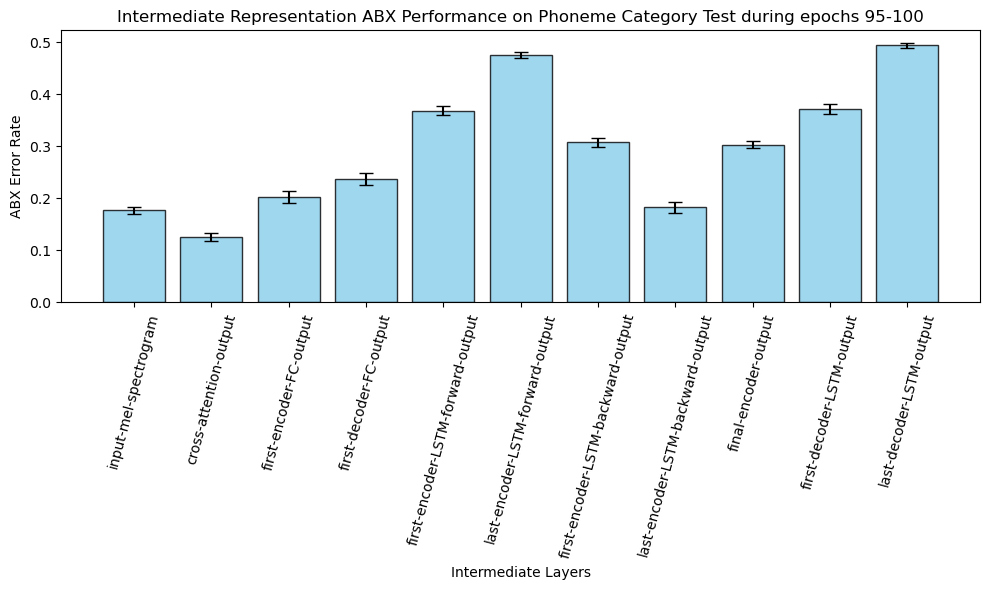

Done.


In [35]:
layered_res = {}
look_for_layer_path = test_name.split("-")[0] + "-" + test_name.split("-")[1] + "-" + test_name.split("-")[2] + "-" + test_name.split("-")[3]
# deal with ori
ori_path = os.path.join(eval_dir, look_for_layer_path, f"07-save-ari-recon64-phi-{balance_type}-{strseq_learned_runs}-ori.npy")
if os.path.exists(ori_path): 
    ori_res = np.load(ori_path)
else: 
    raise ValueError("No ori path found.")
for layer in ["hidrep", "attnout", "dec-lin1", "enc-lin1", 
                "dec-rnn1-f", "enc-rnn1-f", "enc-rnn1-b",
                "dec-rnn2-f", "enc-rnn2-f", "enc-rnn2-b", 
                "dec-rnn3-f", "enc-rnn3-f", "enc-rnn3-b", 
                "dec-rnn4-f", "enc-rnn4-f", "enc-rnn4-b", 
                "dec-rnn5-f", "enc-rnn5-f", "enc-rnn5-b", ]: # "enc-lin1", 
    print(f"Processing {balance_type} in layer {layer}...")
    asp_list_epochs = []
    layer_path = os.path.join(eval_dir, look_for_layer_path, 
                                f"07-save-ari-{model_name}-{balance_type}-{strseq_learned_runs}-{layer}.npy")
    if os.path.exists(layer_path): 
        layer_res = np.load(layer_path)
    else: 
        print(f"Warning: {layer_path} not found. ")
        layer_res = np.zeros_like(ori_res)[:, sample_epoch_start:sample_epoch_end]
    if ori_wise: 
        layered_res[layer] = layer_res[:, sample_epoch_start:sample_epoch_end]/ori_res[:, sample_epoch_start:sample_epoch_end]
    else: 
        layered_res[layer] = layer_res[:, sample_epoch_start:sample_epoch_end]
if ori_wise: 
    layered_res["ori"] = ori_res[:, sample_epoch_start:sample_epoch_end]/ori_res[:, sample_epoch_start:sample_epoch_end]
else: 
    layered_res["ori"] = ori_res[:, sample_epoch_start:sample_epoch_end]

# to_plot_key_order = ["ori", "attnout",  "enc-lin1", "dec-lin1", 
#                 "enc-rnn1-f", "enc-rnn2-f", "enc-rnn3-f", "enc-rnn4-f",
#                 "enc-rnn5-f", 
#                 "enc-rnn1-b", "enc-rnn2-b", "enc-rnn3-b", "enc-rnn4-b",
#                 "enc-rnn5-b", 
#                 "hidrep", 
#                 "dec-rnn1-f", "dec-rnn2-f", "dec-rnn3-f", "dec-rnn4-f", "dec-rnn5-f"]
to_plot_key_order = ["ori", "attnout",  "enc-lin1", "dec-lin1", 
                "enc-rnn1-f", 
                "enc-rnn5-f", 
                "enc-rnn1-b", 
                "enc-rnn5-b", 
                "hidrep", 
                "dec-rnn1-f", 
                "dec-rnn5-f"]
to_plot_name_order = ["input-mel-spectrogram", "cross-attention-output",  "first-encoder-FC-output", "first-decoder-FC-output", 
                "first-encoder-LSTM-forward-output", 
                "last-encoder-LSTM-forward-output", 
                "first-encoder-LSTM-backward-output", 
                "last-encoder-LSTM-backward-output", 
                "final-encoder-output", 
                "first-decoder-LSTM-output", 
                "last-decoder-LSTM-output"]
reordered_values = [layered_res[key] for key in to_plot_key_order]
ori_wise_name = "oriwise" if ori_wise else ""
y_label_name = "ABX Error Rate againts Input Performance" if ori_wise else "ABX Error Rate"
plot_many_matplotlib_errbar(reordered_values, to_plot_name_order, 
            os.path.join(res_save_dir, f"08-stat-{model_name}-{balance_type}-{strseq_learned_runs}-{test_name}-{sample_epoch_start}-{sample_epoch_end}-{ori_wise_name}.png"), 
            plot_label_dict={"xlabel": "Intermediate Layers", 
                             "ylabel": y_label_name, 
                             "title": f"Intermediate Representation ABX Performance on {test_plot_name} during epochs {sample_epoch_start}-{sample_epoch_end}"}, 
            )   # y_range=(0, 0.5)
print("Done.")

In [ ]:
for layer_name, array in zip(to_plot_key_order, reordered_values): 
    # Summarize over trials (axis 0)
    mean_values = array.mean()  # Mean over trials
    std_values = array.std()   # Standard deviation over trials

    print(f"{layer_name}: {mean_values:.3f}; SD = {std_values:.3f}")

ori: 0.482; SD = 0.023
attnout: 0.485; SD = 0.020
enc-lin1: 0.487; SD = 0.020
dec-lin1: 0.492; SD = 0.019
enc-rnn1-f: 0.491; SD = 0.016
enc-rnn2-f: 0.493; SD = 0.016
enc-rnn3-f: 0.491; SD = 0.019
enc-rnn4-f: 0.491; SD = 0.022
enc-rnn5-f: 0.098; SD = 0.041
enc-rnn1-b: 0.488; SD = 0.018
enc-rnn2-b: 0.491; SD = 0.017
enc-rnn3-b: 0.492; SD = 0.014
enc-rnn4-b: 0.494; SD = 0.016
enc-rnn5-b: 0.476; SD = 0.026
hidrep: 0.105; SD = 0.048
dec-rnn1-f: 0.382; SD = 0.112
dec-rnn2-f: 0.342; SD = 0.112
dec-rnn3-f: 0.282; SD = 0.105
dec-rnn4-f: 0.335; SD = 0.069
dec-rnn5-f: 0.092; SD = 0.040


: 

## Plot Trajectory

In [6]:
def plot_many_matplotlib(arrs, labels, save_path, plot_label_dict=None, y_range=None, cloud=True):
    """
    Plots the relation between epoch and ABX error rate using matplotlib.

    Parameters:
    - arrs: List of 2D arrays (num_samples, num_epochs).
    - labels: List of labels for the trajectories.
    - save_path: Path to save the resulting plot image.
    - plot_label_dict: Dictionary with 'xlabel', 'ylabel', and 'title' for the plot.
    - y_range: Optional tuple specifying the y-axis range.
    - cloud: If True, shows confidence interval shading.
    """
    if plot_label_dict is None:
        plot_label_dict = {"xlabel": "Epoch", "ylabel": "ABX Error Rate", "title": "ABX Error Rate Across Epochs"}

    n_steps = arrs[0].shape[1]
    mean_trajs = []
    lower_bounds = []
    upper_bounds = []

    # Calculate means and confidence intervals
    for arr in arrs:
        assert arr.shape[1] == n_steps
        mean_traj = np.mean(arr, axis=0)
        sem_arr = stats.sem(arr, axis=0)
        ci_95 = 1.96 * sem_arr  # 95% confidence interval
        upper_bound = mean_traj + ci_95
        lower_bound = mean_traj - ci_95
        mean_trajs.append(mean_traj)
        lower_bounds.append(lower_bound)
        upper_bounds.append(upper_bound)

    # Generate the plot
    fig, ax = plt.subplots(figsize=(10, 6))
    epochs = np.arange(n_steps)

    for idx, (mean_traj, lower_bound, upper_bound, label) in enumerate(zip(mean_trajs, lower_bounds, upper_bounds, labels)):
        if cloud:
            # Confidence interval shading
            ax.fill_between(
                epochs,
                lower_bound,
                upper_bound,
                color=f"C{idx}",
                alpha=0.2,
                label=None  # Label CI once
            )
        # Mean trajectory
        ax.plot(
            epochs,
            mean_traj,
            label=label,
            color=f"C{idx}",
            linewidth=2
        )

    # Customize plot
    ax.set_xlabel(plot_label_dict["xlabel"])
    ax.set_ylabel(plot_label_dict["ylabel"])
    ax.set_title(plot_label_dict["title"])
    # Set legend outside the plot
    ax.legend(loc="upper left", bbox_to_anchor=(1.05, 1.0), borderaxespad=0.)
    if y_range:
        ax.set_ylim(y_range)

    # Save and display
    # Adjust layout to make room for the legend
    plt.tight_layout(rect=[0, 0, 0.9, 1])  # Leave space on the right for the legend
    plt.savefig(save_path)
    plt.show()


In [22]:
train_name = "E_0A"
ts = "1113024340"
eval_dir = os.path.join(model_save_, f"eval-{train_name}-{ts}")
dim = 16
balance_type = "b"
strseq_learned_runs = "12345"
# test_name = "ABXSomethingCrossPhone-first_third-data-AA"
# test_name = "ABXSomething-first-data-AAIY_1"
test_name = "ABXSomething-third-data-AAIY_3"
# test_name = "ABXSomething-third-data-speaker"
# test_name = "ABXSomething-third-data-SSH"
# test_plot_name = "Phoneme Position Test"
test_plot_name = "Phoneme Category Test"
# test_plot_name = "Non-linguistic Test"
# test_plot_name = ""
model_name = f"recon{dim}-phi"
res_save_dir = os.path.join(eval_dir, f"PLOTS_20250201")
mk(res_save_dir)
sample_epoch_start = 1
sample_epoch_end = 101
ori_wise = True

## Draw End Epochs

Processing b in layer hidrep...
Processing b in layer attnout...
Processing b in layer dec-lin1...
Processing b in layer enc-lin1...
Processing b in layer dec-rnn1-f...
Processing b in layer enc-rnn1-f...
Processing b in layer enc-rnn1-b...
Processing b in layer dec-rnn2-f...
Processing b in layer enc-rnn2-f...
Processing b in layer enc-rnn2-b...
Processing b in layer dec-rnn3-f...
Processing b in layer enc-rnn3-f...
Processing b in layer enc-rnn3-b...
Processing b in layer dec-rnn4-f...
Processing b in layer enc-rnn4-f...
Processing b in layer enc-rnn4-b...
Processing b in layer dec-rnn5-f...
Processing b in layer enc-rnn5-f...
Processing b in layer enc-rnn5-b...


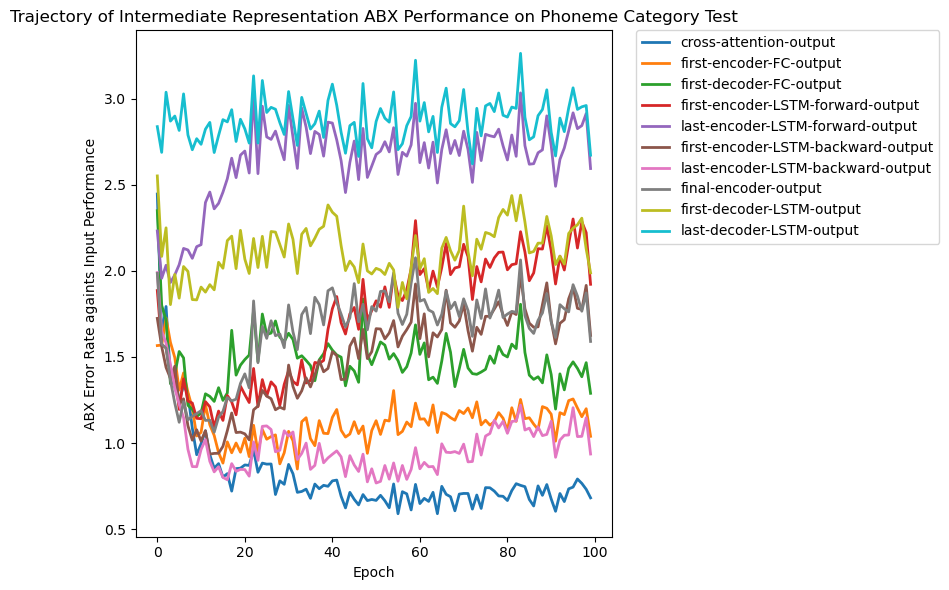

Done.


In [23]:
layered_res = {}
look_for_layer_path = test_name.split("-")[0] + "-" + test_name.split("-")[1] + "-" + test_name.split("-")[2] + "-" + test_name.split("-")[3]
# deal with ori
ori_path = os.path.join(eval_dir, look_for_layer_path, f"07-save-ari-recon64-phi-{balance_type}-{strseq_learned_runs}-ori.npy")
if os.path.exists(ori_path): 
    ori_res = np.load(ori_path)
else: 
    raise ValueError("No ori path found.")
for layer in ["hidrep", "attnout", "dec-lin1", "enc-lin1", 
                "dec-rnn1-f", "enc-rnn1-f", "enc-rnn1-b",
                "dec-rnn2-f", "enc-rnn2-f", "enc-rnn2-b", 
                "dec-rnn3-f", "enc-rnn3-f", "enc-rnn3-b", 
                "dec-rnn4-f", "enc-rnn4-f", "enc-rnn4-b", 
                "dec-rnn5-f", "enc-rnn5-f", "enc-rnn5-b", ]: # "enc-lin1", 
    print(f"Processing {balance_type} in layer {layer}...")
    asp_list_epochs = []
    layer_path = os.path.join(eval_dir, look_for_layer_path, 
                                f"07-save-ari-{model_name}-{balance_type}-{strseq_learned_runs}-{layer}.npy")
    if os.path.exists(layer_path): 
        layer_res = np.load(layer_path)
    else: 
        print(f"Warning: {layer_path} not found. ")
        layer_res = np.zeros_like(ori_res)[:, sample_epoch_start:sample_epoch_end]
    if ori_wise: 
        layered_res[layer] = layer_res[:, sample_epoch_start:sample_epoch_end]/ori_res[:, sample_epoch_start:sample_epoch_end]
    else: 
        layered_res[layer] = layer_res[:, sample_epoch_start:sample_epoch_end]
if ori_wise: 
    layered_res["ori"] = ori_res[:, sample_epoch_start:sample_epoch_end]/ori_res[:, sample_epoch_start:sample_epoch_end]
else: 
    layered_res["ori"] = ori_res[:, sample_epoch_start:sample_epoch_end]

# to_plot_key_order = ["attnout",  "enc-lin1", "dec-lin1", 
#                 "enc-rnn1-f", "enc-rnn2-f", "enc-rnn3-f", "enc-rnn4-f",
#                 "enc-rnn5-f", 
#                 "enc-rnn1-b", "enc-rnn2-b", "enc-rnn3-b", "enc-rnn4-b",
#                 "enc-rnn5-b", 
#                 "hidrep", 
#                 "dec-rnn1-f", "dec-rnn2-f", "dec-rnn3-f", "dec-rnn4-f", 
#                 "dec-rnn5-f"]
to_plot_key_order = ["attnout",  "enc-lin1", "dec-lin1", 
                "enc-rnn1-f", 
                "enc-rnn5-f", 
                "enc-rnn1-b", 
                "enc-rnn5-b", 
                "hidrep", 
                "dec-rnn1-f", 
                "dec-rnn5-f"]
to_plot_name_order = ["cross-attention-output",  "first-encoder-FC-output", "first-decoder-FC-output", 
                "first-encoder-LSTM-forward-output", 
                "last-encoder-LSTM-forward-output", 
                "first-encoder-LSTM-backward-output", 
                "last-encoder-LSTM-backward-output", 
                "final-encoder-output", 
                "first-decoder-LSTM-output", 
                "last-decoder-LSTM-output"]
reordered_values = [layered_res[key] for key in to_plot_key_order]
ori_wise_name = "oriwise" if ori_wise else ""
y_label_name = "ABX Error Rate againts Input Performance" if ori_wise else "ABX Error Rate"
plot_many_matplotlib(reordered_values, to_plot_name_order, 
            os.path.join(res_save_dir, f"09-traj-{model_name}-{balance_type}-{strseq_learned_runs}-{test_name}-{sample_epoch_start}-{sample_epoch_end}-{ori_wise_name}.png"), 
            plot_label_dict={"xlabel": "Epoch", 
                             "ylabel": y_label_name, 
                             "title": f"Trajectory of Intermediate Representation ABX Performance on {test_plot_name}"}, 
            cloud=False
            )   # y_range=(0, 0.5)
print("Done.")

In [35]:
reordered_values[0].shape

(30, 101)

In [36]:
import pandas as pd
import numpy as np
# Create a list of dictionaries for the DataFrame
data = []
for layer_name, array in zip(to_plot_key_order, reordered_values):
    # Summarize over trials (axis 0)
    mean_values = array.mean(axis=0)  # Mean over trials
    std_values = array.std(axis=0)   # Standard deviation over trials
    for epoch, (mean, std) in enumerate(zip(mean_values, std_values), start=0): 
        data.append({"LAYER": layer_name, "EPOCH": epoch, "MEAN": mean, "SD": std})

# Create a pandas DataFrame
df = pd.DataFrame(data)

# Save DataFrame to a CSV file
output_file = "layer_summary.csv"
df.to_csv(os.path.join(res_save_dir, 
                       f"09-traj-{model_name}-{balance_type}-{strseq_learned_runs}-{test_name}-{sample_epoch_start}-{sample_epoch_end}-{ori_wise_name}.csv"), index=False)

print(f"Data has been written to {output_file}")


Data has been written to layer_summary.csv


In [37]:
for layer_name, array in zip(to_plot_key_order, reordered_values): 
    # Summarize over trials (axis 0)
    mean_values = array.mean(axis=0)  # Mean over trials
    std_values = array.std(axis=0)   # Standard deviation over trials
    min_val = np.min(mean_values)
    min_epoch = np.argmin(mean_values)

    print(f"{layer_name}: {mean_values[0]:.3f} at epoch 0; {min_val:.3f} at epoch {min_epoch}; {mean_values[99]:.3f} at epoch 99")

attnout: 1.030 at epoch 0; 0.643 at epoch 1; 1.025 at epoch 99
enc-lin1: 0.983 at epoch 0; 0.978 at epoch 22; 1.031 at epoch 99
dec-lin1: 1.018 at epoch 0; 0.550 at epoch 1; 1.030 at epoch 99
enc-rnn1-f: 1.012 at epoch 0; 0.492 at epoch 1; 1.023 at epoch 99
enc-rnn2-f: 0.979 at epoch 0; 0.566 at epoch 1; 1.034 at epoch 99
enc-rnn3-f: 0.917 at epoch 0; 0.560 at epoch 1; 1.038 at epoch 99
enc-rnn4-f: 0.835 at epoch 0; 0.394 at epoch 3; 1.029 at epoch 99
enc-rnn5-f: 0.672 at epoch 0; 0.056 at epoch 8; 0.213 at epoch 99
enc-rnn1-b: 0.991 at epoch 0; 0.839 at epoch 15; 1.032 at epoch 99
enc-rnn2-b: 0.990 at epoch 0; 0.404 at epoch 4; 1.031 at epoch 99
enc-rnn3-b: 0.934 at epoch 0; 0.311 at epoch 3; 1.022 at epoch 99
enc-rnn4-b: 0.812 at epoch 0; 0.468 at epoch 1; 1.043 at epoch 99
enc-rnn5-b: 0.638 at epoch 0; 0.488 at epoch 3; 0.991 at epoch 99
hidrep: 0.595 at epoch 0; 0.057 at epoch 5; 0.225 at epoch 99
dec-rnn1-f: 0.446 at epoch 0; 0.220 at epoch 2; 0.808 at epoch 99
dec-rnn2-f: 0.432 a